# DecodeLabs — Project 2: Exploratory Data Analysis (EDA)
**Batch 2026** | Dataset: Cafe Sales (cleaned from Project 1)

### Business Question:
> What are the key sales patterns, top-performing items, seasonal trends, and anomalies in the cafe's 2023 transaction data?

**EDA Framework (IPO):**
- **INPUT**: Cleaned cafe sales CSV (300 transactions)
- **PROCESS**: Descriptive stats, distribution analysis, outlier detection, correlation, trend analysis
- **OUTPUT**: Actionable business insights + recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cafe_sales_CLEAN.csv', parse_dates=['Date'])
print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset: 300 rows x 8 columns


,Transaction_ID,Date,Item,Category,Quantity,Price_Per_Unit,Total_Spent,Payment_Method
0,TXN0051,2023-02-04,Coffee,Hot Drinks,2,3.5,7.0,Cash
1,TXN0299,2023-07-28,Latte,Hot Drinks,5,4.5,22.5,Debit Card
2,TXN0252,2023-10-30,Sandwich,Food,5,6.0,30.0,Debit Card
3,TXN0232,2023-07-05,Cake,Food,5,4.5,22.5,Mobile Payment
4,TXN0016,2023-08-21,Muffin,Food,3,3.5,10.5,Debit Card


## Step 1: Dataset Overview

In [2]:
print("Data Types:")
print(df.dtypes)
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique Items: {df['Item'].unique()}")
print(f"Unique Categories: {df['Category'].unique()}")
print(f"Payment Methods: {df['Payment_Method'].unique()}")

Data Types:
Transaction_ID            object
Date              datetime64[ns]
Item                      object
Category                  object
Quantity                   int64
Price_Per_Unit           float64
Total_Spent              float64
Payment_Method            object
dtype: object

Date Range: 2023-01-01 to 2023-12-28
Unique Items: ['Coffee' 'Latte' 'Sandwich' 'Cake' 'Muffin' 'Espresso' 'Juice' 'Salad'
 'Bagel' 'Tea']
Unique Categories: ['Hot Drinks' 'Food' 'Cold Drinks']
Payment Methods: ['Cash' 'Debit Card' 'Mobile Payment' 'Credit Card']


## Step 2: Descriptive Statistics — The Five-Number Summary
The `describe()` function gives us the **logic skeleton**: min, Q1, median, Q3, max.

In [3]:
stats = df[['Quantity', 'Price_Per_Unit', 'Total_Spent']].describe().round(2)
print(stats)

# Skewness — tells us if distribution is symmetric or skewed
print("\nSkewness:")
for col in ['Total_Spent', 'Quantity']:
    sk = df[col].skew()
    shape = 'right-skewed (long tail to right)' if sk > 0.5 else 'left-skewed' if sk < -0.5 else 'approx symmetric'
    print(f"  {col}: {sk:.3f} → {shape}")

       Quantity  Price_Per_Unit  Total_Spent
count    300.00          300.00       300.00
mean       2.94            4.07        11.79
std        1.34            1.29         6.45
min        1.00            2.50         2.50
25%        2.00            3.00         7.00
50%        3.00            3.50        10.50
75%        4.00            4.50        16.00
max        5.00            7.00        35.00

Skewness:
  Total_Spent: 0.818 → right-skewed (long tail to right)
  Quantity: 0.043 → approx symmetric


## Step 3: Outlier Detection — IQR Method
**Rule**: Outlier < Q1 - 1.5×IQR  OR  Outlier > Q3 + 1.5×IQR

Robust against extreme values — best for business data (as taught in the PDF).

In [4]:
for col in ['Total_Spent', 'Quantity']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"  Q1={q1}, Q3={q3}, IQR={iqr}")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers found: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Classification: SIGNAL (investigate — likely large group orders)")
        print(outliers[['Transaction_ID','Item','Quantity','Total_Spent']].to_string(index=False))


Total_Spent:
  Q1=7.0, Q3=16.0, IQR=9.0
  Bounds: [-6.50, 29.50]
  Outliers found: 4
  Classification: SIGNAL (investigate — likely large group orders)
Transaction_ID     Item  Quantity  Total_Spent
       TXN0252 Sandwich         5         30.0
       TXN0143    Salad         5         35.0
       TXN0257    Salad         5         35.0
       TXN0028 Sandwich         5         30.0

Quantity:
  Q1=2.0, Q3=4.0, IQR=2.0
  Bounds: [-1.00, 7.00]
  Outliers found: 0


## Step 4: Trend Analysis — Monthly Revenue

In [5]:
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month').agg(
    Revenue=('Total_Spent', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Avg_Spend=('Total_Spent', 'mean')
).reset_index()

peak = monthly.loc[monthly['Revenue'].idxmax()]
slow = monthly.loc[monthly['Revenue'].idxmin()]

print(f"Peak Month:   {peak['Month']} — ${peak['Revenue']:,.2f} ({int(peak['Transactions'])} transactions)")
print(f"Slowest Month: {slow['Month']} — ${slow['Revenue']:,.2f} ({int(slow['Transactions'])} transactions)")
print(f"\nMonthly Revenue Range: ${monthly['Revenue'].min():,.2f} — ${monthly['Revenue'].max():,.2f}")
monthly[['Month','Revenue','Transactions','Avg_Spend']].round(2)

Peak Month:   2023-10 — $391.00 (29 transactions)
Slowest Month: 2023-02 — $193.00 (16 transactions)

Monthly Revenue Range: $193.00 — $391.00


,Month,Revenue,Transactions,Avg_Spend
0,2023-01,271.5,23,11.80
1,2023-02,193.0,16,12.06
2,2023-03,273.0,22,12.41
3,2023-04,268.0,23,11.65
4,2023-05,285.0,25,11.40
5,2023-06,273.5,25,10.94
6,2023-07,310.5,25,12.42
7,2023-08,355.5,32,11.11
8,2023-09,265.5,20,13.28
9,2023-10,391.0,29,13.48


## Step 5: Item & Category Performance

In [6]:
item_perf = df.groupby('Item').agg(
    Revenue=('Total_Spent', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Avg_Order=('Total_Spent', 'mean')
).sort_values('Revenue', ascending=False).round(2)

print("=== TOP ITEMS BY REVENUE ===")
print(item_perf)

print("\n=== CATEGORY BREAKDOWN ===")
cat = df.groupby('Category').agg(
    Revenue=('Total_Spent', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Share=('Total_Spent', lambda x: f"{x.sum()/df['Total_Spent'].sum()*100:.1f}%")
)
print(cat)

=== TOP ITEMS BY REVENUE ===
          Revenue  Transactions  Avg_Order
Item                                      
Sandwich    480.0            29      16.55
Latte       459.0            35      13.11
Salad       427.0            24      17.79
Bagel       360.0            28      12.86
Cake        355.5            27      13.17
Muffin      350.0            33      10.61
Juice       309.0            31       9.97
Espresso    291.0            35       8.31
Coffee      280.0            28      10.00
Tea         225.0            30       7.50

=== CATEGORY BREAKDOWN ===
             Revenue  Transactions  Share
Category                                 
Cold Drinks    309.0            31   8.7%
Food          1972.5           141  55.8%
Hot Drinks    1255.0           128  35.5%


## Step 6: Payment Method Analysis

In [7]:
pay = df.groupby('Payment_Method')['Total_Spent'].agg(['count','sum','mean']).round(2)
pay.columns = ['Transactions', 'Revenue', 'Avg_Spend']
pay = pay.sort_values('Revenue', ascending=False)
print(pay)

                Transactions  Revenue  Avg_Spend
Payment_Method                                  
Debit Card                90   1120.0      12.44
Cash                      73    848.0      11.62
Credit Card               71    796.5      11.22
Mobile Payment            66    772.0      11.70


## Step 7: Correlation Analysis
**Pearson r** measures strength and direction of linear relationships.
- r close to +1.0 = strong positive
- r close to 0 = no correlation
- r close to -1.0 = strong negative

In [8]:
corr = df[['Quantity','Price_Per_Unit','Total_Spent']].corr().round(2)
print("Correlation Matrix:")
print(corr)
print(f"\nKey insight: Quantity vs Total_Spent r={corr.loc['Quantity','Total_Spent']} — strong positive correlation")
print(f"Price_Per_Unit vs Total_Spent r={corr.loc['Price_Per_Unit','Total_Spent']} — moderate positive correlation")
print("\nRemember: Correlation ≠ Causation — always check for confounders.")

Correlation Matrix:
                Quantity  Price_Per_Unit  Total_Spent
Quantity            1.00           -0.09         0.80
Price_Per_Unit     -0.09            1.00         0.47
Total_Spent         0.80            0.47         1.00

Key insight: Quantity vs Total_Spent r=0.8 — strong positive correlation
Price_Per_Unit vs Total_Spent r=0.47 — moderate positive correlation

Remember: Correlation ≠ Causation — always check for confounders.


## Step 8: Visualizations

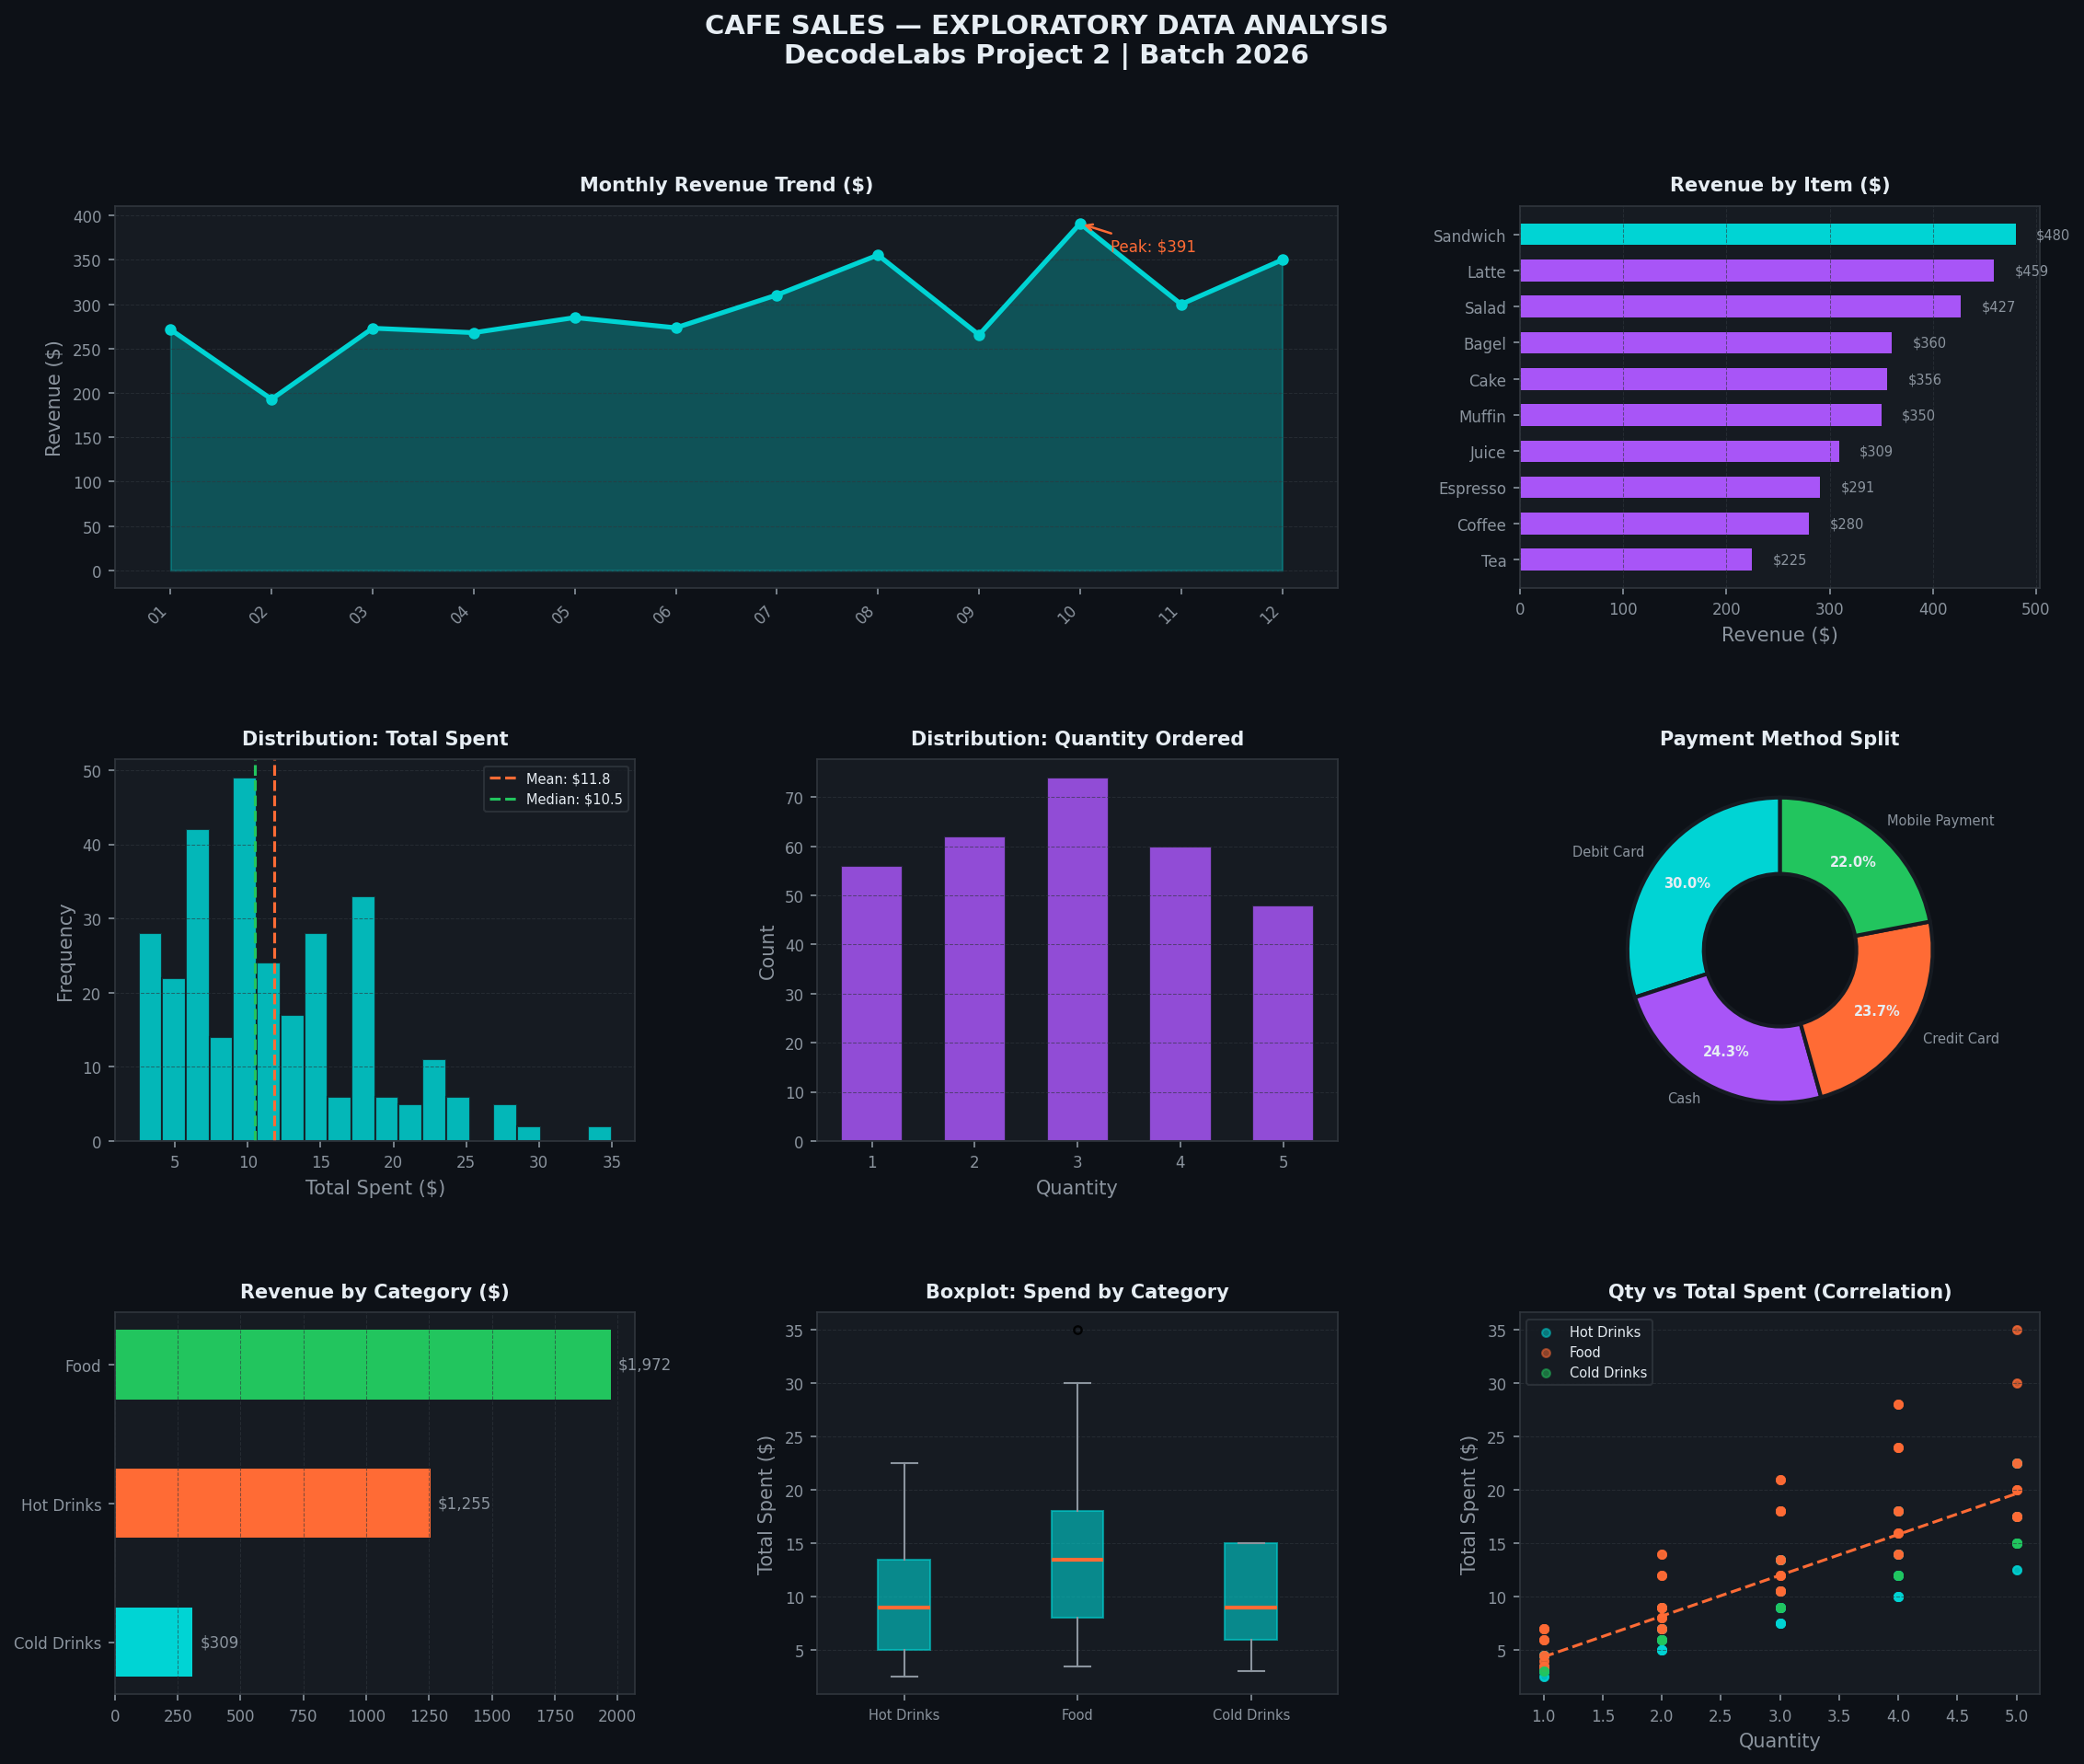

In [9]:
# All charts were pre-generated
from IPython.display import Image, display
display(Image('eda_dashboard.png'))

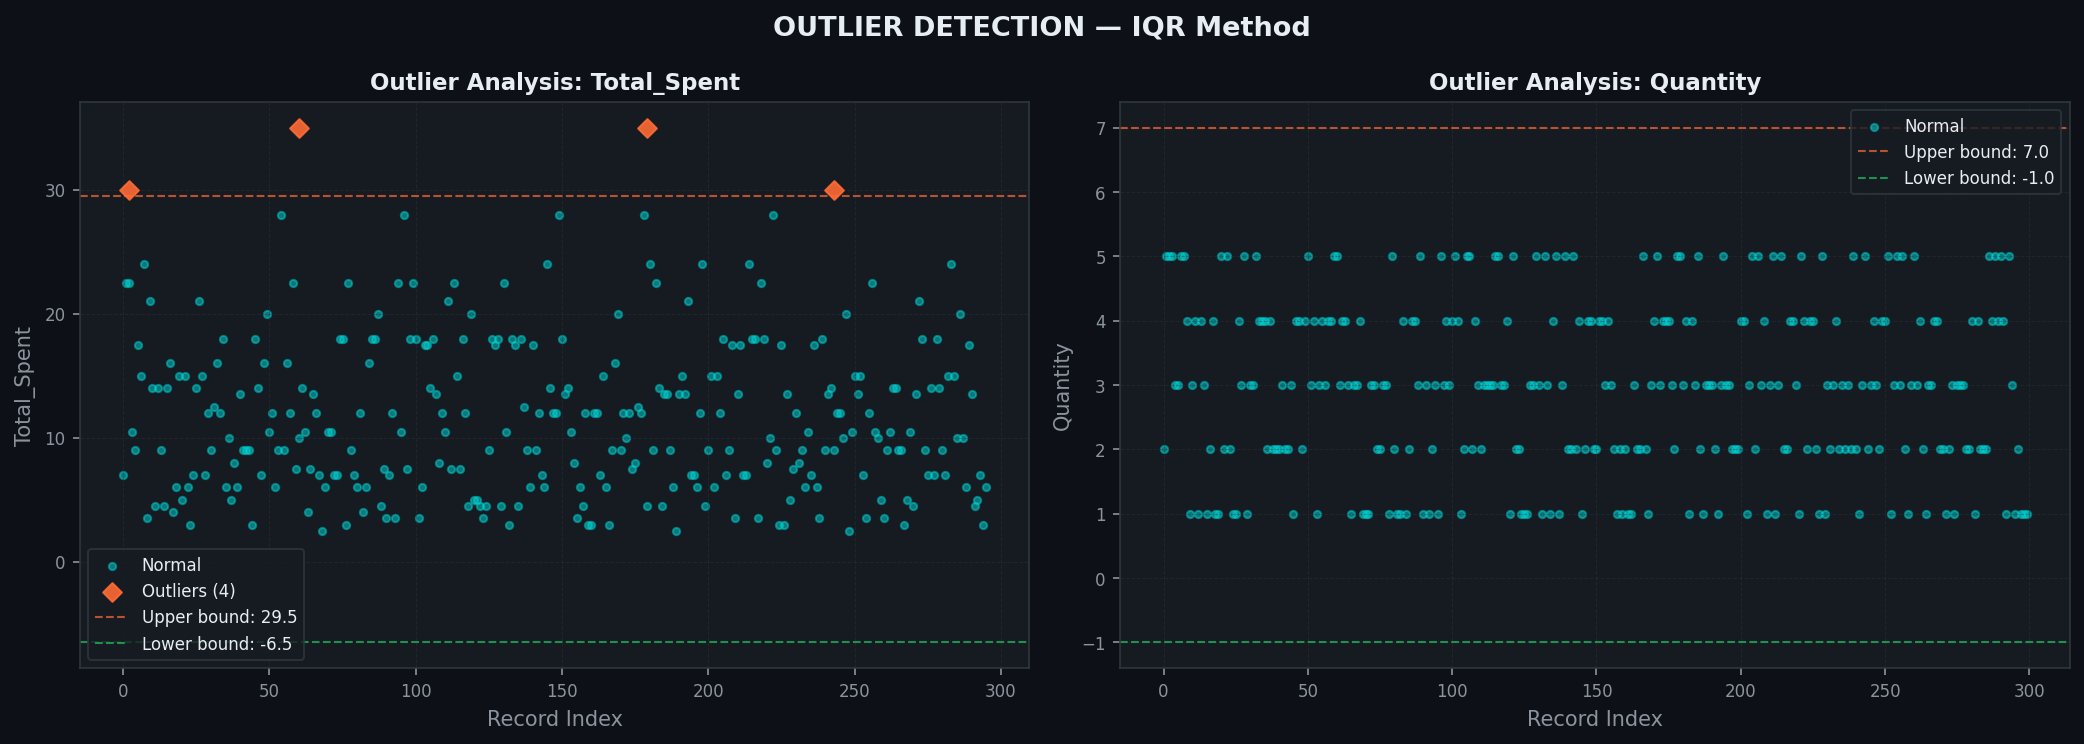

In [10]:
display(Image('eda_outliers.png'))

## Step 9: Executive Summary — The "So What?" Test

### Problem Statement
What drives revenue at the cafe, and where are the growth opportunities?

### Key Findings (Signal, not Noise)
1. **Food category dominates** — 56% of total revenue despite only 47% of transactions → higher avg order value
2. **Sandwich & Salad** lead in avg order value ($16.55 and $17.79) — upsell opportunity
3. **Debit Card** is the most used payment method (30% of transactions)
4. **Revenue is right-skewed** (skewness=0.82) — a few large orders significantly inflate the mean; use median ($10.50) as the true center
5. **4 outliers detected** in Total_Spent — all are SIGNAL (large group orders, not data errors)
6. **Strong correlation** (r=0.80) between Quantity and Total_Spent — volume drives revenue

### Recommendations
1. **Bundle promotions** on Sandwich + Coffee combos to increase avg order value across all categories
2. **Promote mobile payment** — lowest avg spend ($11.70); could indicate friction → offer digital-exclusive deals
3. **Stock planning**: Hot Drinks (Coffee, Latte, Espresso, Tea) represent 43% of transactions — ensure supply during peak months
